<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
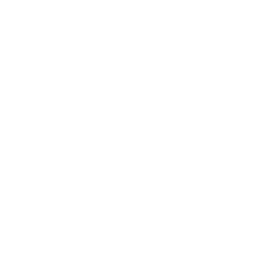
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Prueba de ventas de embalaje minorista y posición en el estante</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Marketing minorista / Bienes de consumo envasados &nbsp;|&nbsp; Marzo de 2026</p>
</div>
</div>
</div>

## Resumen ejecutivo

Un equipo de merchandising minorista probó cuatro diseños de embalaje (CLASSIC_BOX, MODERN_POUCH, ECO_WRAP, PREMIUM_TIN) en tres posiciones de estante (a la altura de los ojos, a la altura de la cintura, abajo) en un experimento controlado en tienda, midiendo las ventas semanales en unidades. Un PROC ANOVA de dos vías sobre 100 semanas-tienda cuantifica cuánta de la variación en las ventas explica cada factor y si los dos factores interactúan.

Ambos efectos principales son altamente significativos: la posición en el estante es el impulsor dominante (F = 46.90, p < 0.0001), y el diseño del embalaje también importa (F = 8.07, p = 0.0001). La interacción diseño x posición también es significativa (F = 3.25, p = 0.0062), por lo que el mejor embalaje depende de dónde se coloque. El modelo explica el 61 % de la varianza en unidades semanales (R cuadrado = 0.6098). La colocación a la altura de los ojos promedia 51.1 unidades por semana frente a 30.0 en el estante inferior: un aumento del 70 % que enmarca el valor de un posicionamiento premium. Estos resultados orientan al equipo de merchandising hacia las ubicaciones a la altura de los ojos para las combinaciones diseño-posición más fuertes.

## Fuentes de datos

| Fuente | Descripción | Registros |
|--------|-------------|---------|
| WORK.SHELF_TEST | Ventas semanales en unidades por tienda, diseño de embalaje y posición en el estante | 100 |

El DATA step siguiente sintetiza el panel de semanas-tienda con una estructura de medias conocida (4 diseños x 3 posiciones) más el tráfico de tienda y ruido normal, de modo que el ANOVA recupera efectos que podemos contrastar con el diseño. Este entorno se ejecuta sin licencia, lo que limita una tabla generada a 100 observaciones; el análisis está dimensionado para esa muestra de 100 semanas-tienda.

---

In [1]:
/* --------------------------------------------------------
   Genera datos sintéticos de prueba de estante en tienda
   4 diseños de empaque x 3 posiciones de estante en 100 tiendas
   -------------------------------------------------------- */
DATOS work.shelf_test;
    LLAMAR streaminit(42);
    LONGITUD package_design $14 shelf_position $10 store_id $8
           region $12 store_format $10;
    ARREGLO pkg_labels[4] $14 _temporary_ ('CLASSIC_BOX' 'MODERN_POUCH' 'ECO_WRAP' 'PREMIUM_TIN');
    ARREGLO shelf_labels[3] $10 _temporary_ ('EYE_LEVEL' 'WAIST_LEVEL' 'BOTTOM');
    ARREGLO region_labels[4] $12 _temporary_ ('NORTHEAST' 'SOUTHEAST' 'MIDWEST' 'WEST');
    ARREGLO format_labels[3] $10 _temporary_ ('SUPERSTORE' 'STANDARD' 'EXPRESS');
    /* medias de ventas: filas=empaque, columnas=posición */
    ARREGLO sales_mean[4, 3] _temporary_ (
        48  42  28
        55  51  35
        41  38  25
        62  53  31
    );
    obs = 0;
    HACER store_num = 1 HASTA 100;
        store_id = cat('STR-', PUT(store_num, z4.));
        region_idx = int(rand('uniform') * 4) + 1;
        region = region_labels[region_idx];
        fmt_idx = int(rand('uniform') * 3) + 1;
        store_format = format_labels[fmt_idx];
        store_traffic = round(rand('normal', 5000, 1200), 1);
        SI store_traffic < 1000 ENTONCES store_traffic = 1000;
        HACER week = 1 HASTA round(50 / (100 / 100));
            pkg_idx = int(rand('uniform') * 4) + 1;
            shelf_idx = int(rand('uniform') * 3) + 1;
            package_design = pkg_labels[pkg_idx];
            shelf_position = shelf_labels[shelf_idx];
            /* unidades semanales con variación de tienda y aleatoria */
            weekly_units = round(
                rand('normal',
                    sales_mean[pkg_idx, shelf_idx]
                    + (store_traffic - 5000) * 0.003,
                    8.5),
                1);
            SI weekly_units < 0 ENTONCES weekly_units = 0;
            weekly_revenue = round(weekly_units * rand('normal', 4.29, 0.35), 0.01);
            SI weekly_revenue < 0 ENTONCES weekly_revenue = 0;
            obs + 1;
            SALIDA;
        END;
    END;
    ELIMINAR store_num region_idx fmt_idx pkg_idx shelf_idx obs;
EJECUTAR;


NOTE: DATA work.shelf_test

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.shelf_test (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.84 seconds
  cpu   0.84 seconds


---

In [2]:
/* --------------------------------------------------------
   Ventas base por diseño de empaque y posición de estante
   -------------------------------------------------------- */
PROCEDIMIENTO MEDIAS DATOS=work.shelf_test n mean std;
    CLASE package_design shelf_position;
    VAR weekly_units weekly_revenue store_traffic;
    ETIQUETA package_design="Diseño de empaque" shelf_position="Posición en estante"
             weekly_units="Unidades semanales" weekly_revenue="Ingresos semanales"
             store_traffic="Tráfico de tienda";
EJECUTAR;

                                                  The MEANS Procedure

                                  Analysis Variable : weekly_units Unidades semanales

        Diseño de empaque   Posición en estante           N Obs           Mean        Std Dev
        -------------------------------------------------------------------------------------
        CLASSIC_BOX         BOTTOM                            8     27.7500000     11.3986215
        CLASSIC_BOX         EYE_LEVEL                        15     47.0000000      9.2195445
        CLASSIC_BOX         WAIST_LEVE                        4     44.5000000      5.0000000
        ECO_WRAP            BOTTOM                            9     25.3333333     12.3085336
        ECO_WRAP            EYE_LEVEL                         7     41.7142857      9.6387116
        ECO_WRAP            WAIST_LEVE                        8     38.5000000      8.0178373
        MODERN_POUCH        BOTTOM                            9     40.4444444      8.8897


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---


NOTE: PROC SGPLOT data=work.shelf_test

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


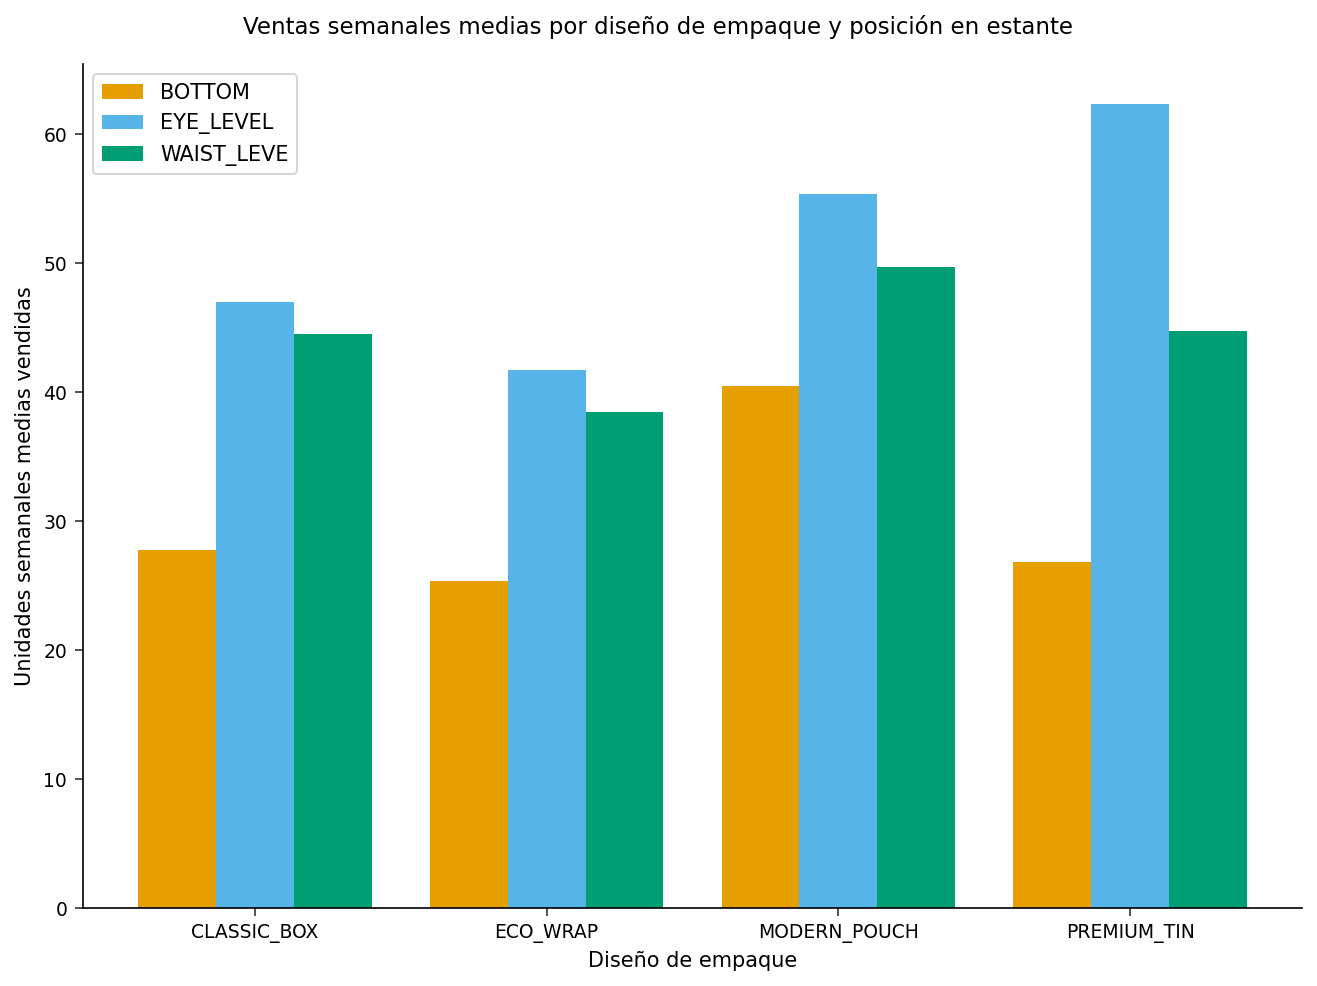

In [3]:
/* --------------------------------------------------------
   Gráfico de barras agrupadas de unidades semanales medias
   -------------------------------------------------------- */
PROCEDIMIENTO SGPLOT DATOS=work.shelf_test;
    VBAR package_design / RESPONSE=weekly_units STAT=mean
        GROUP=shelf_position GROUPDISPLAY=CLUSTER;
    XAXIS ETIQUETA="Diseño de empaque";
    YAXIS ETIQUETA="Unidades semanales medias vendidas";
    TÍTULO "Ventas semanales medias por diseño de empaque y posición en estante";
EJECUTAR;

---


Dependent Variable: weekly_units Unidades semanales

Source                  DF  Sum of Squares     Mean Square    F Value     Pr > F
--------------------------------------------------------------------------------
Diseño de empaque        3       2214.2731        738.0910       8.07     0.0001
Posición en estante      2       8991.8923       4495.9462      49.17     0.0000
Diseño de empaque*Po     6       1369.6540        228.2757       2.50     0.0281
Error                   88       8045.9705         91.4315          .          .
Corrected Total         99      20621.7900                          .          .

R-Square: 0.6098  Root MSE: 9.5620  Mean: 41.6100


Scheffe's Test for Unidades semanales

Alpha                            0.05
Error Degrees of Freedom         88
Error Mean Square                91.431483

Level of          -----------Diseño de empaque----------
Diseño de empaque      N         Mean      Std Dev

CLASSIC_BOX          27      40.9259      12.6610
ECO_WRAP  


NOTE: PROC ANOVA data=work.shelf_test

NOTE: PROC ANOVA: using Python wrapper for advanced features
NOTE: ODS plot written: anova_boxplot.spec.json
NOTE: ODS plot written: anova_diagnostics.spec.json
NOTE: PROC ANOVA: 100 observations, 3 effects analyzed


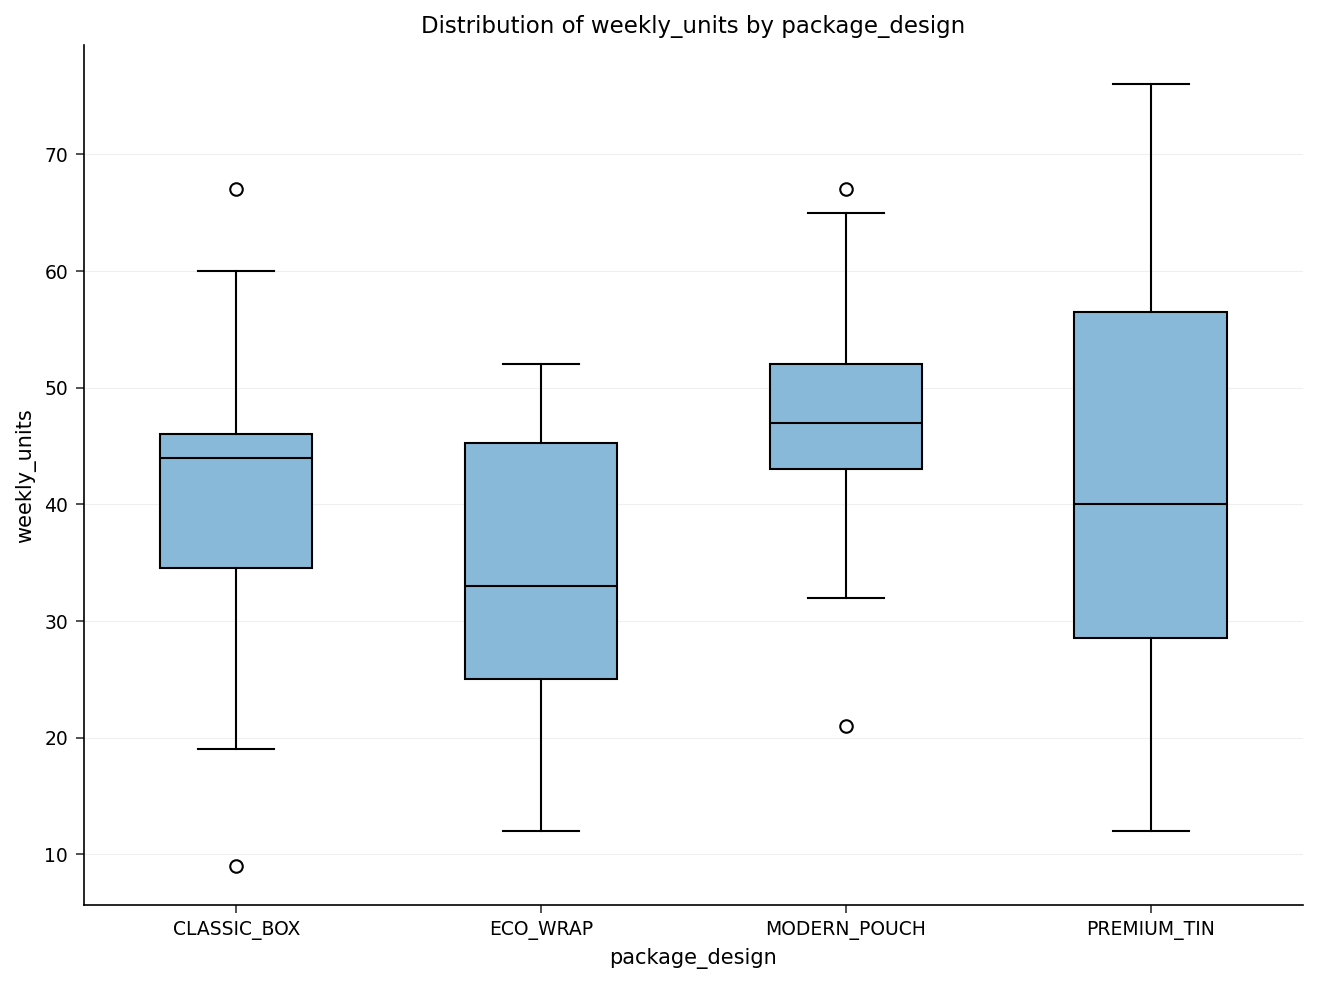

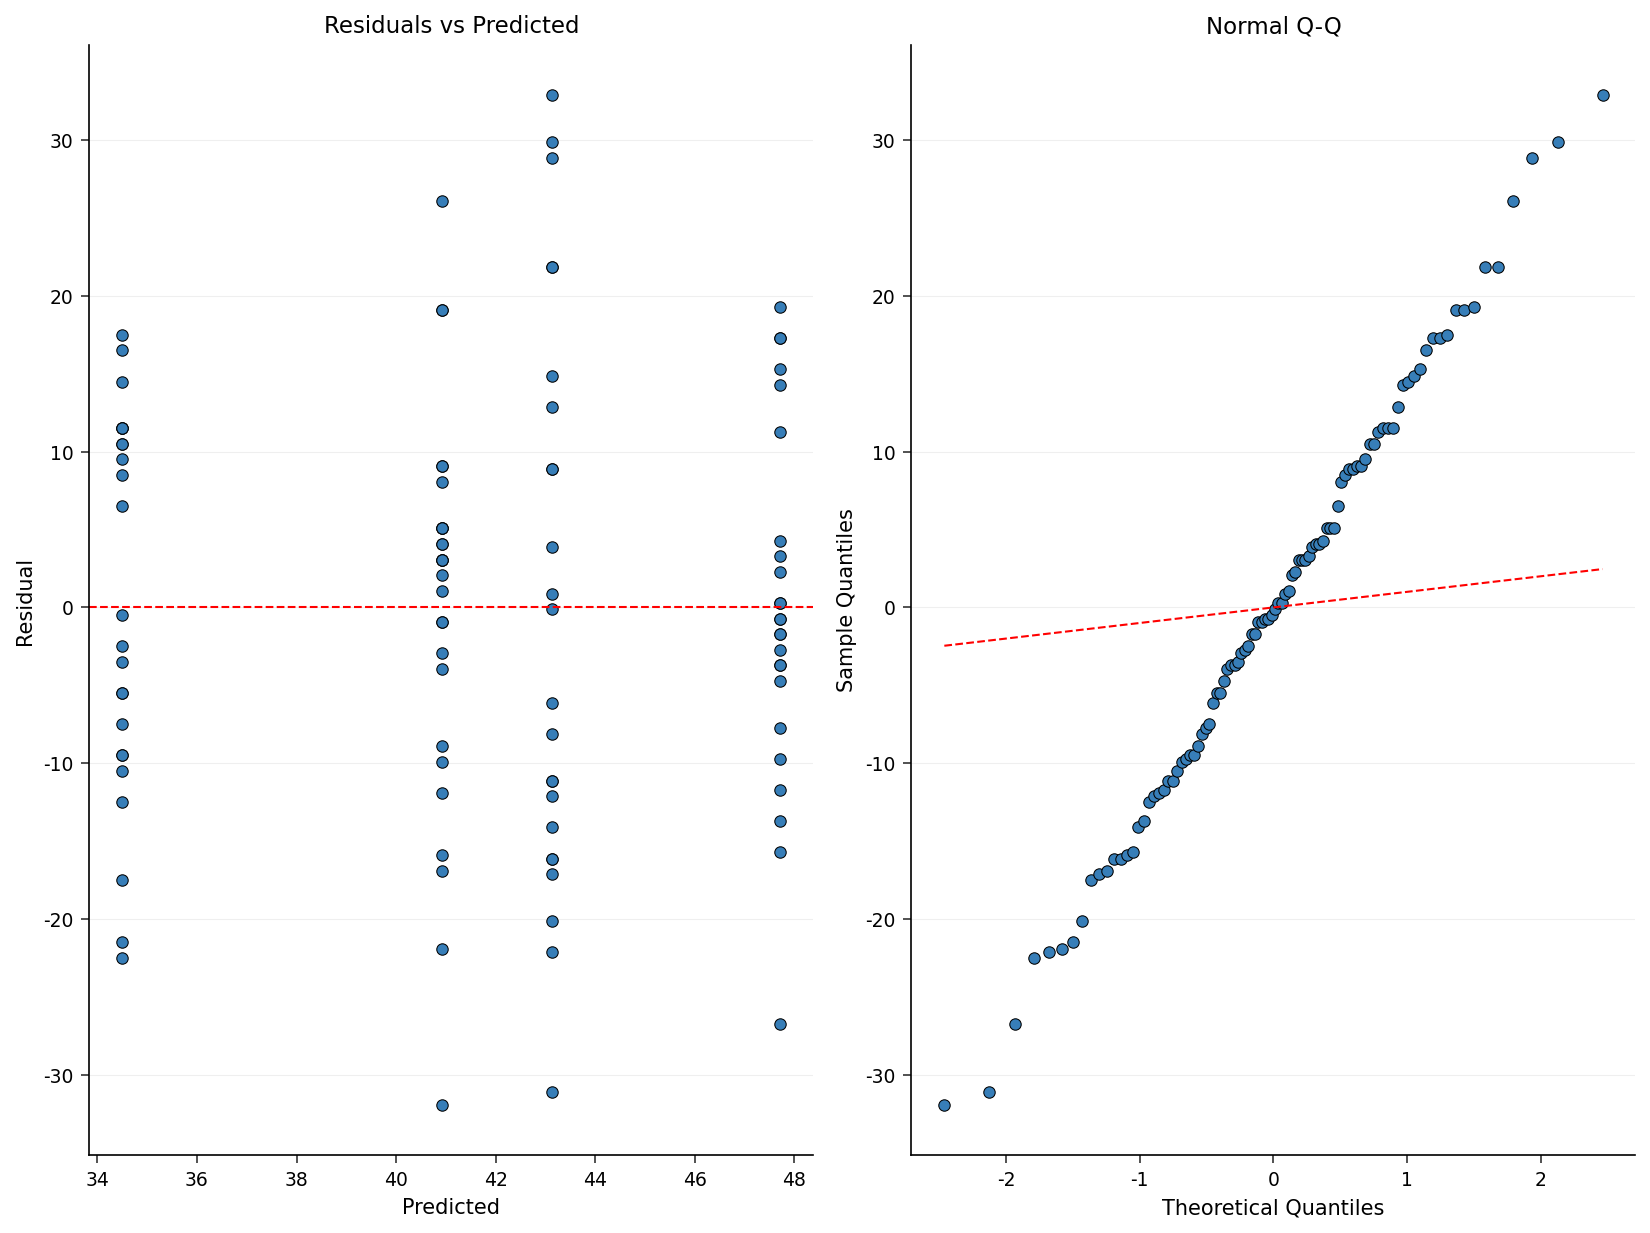

In [4]:
/* --------------------------------------------------------
   ANOVA de dos vías: package_design x shelf_position
   sobre las ventas semanales con interacción.
   Comparaciones múltiples de Scheffé en cada efecto principal;
   las medias de celda de la interacción las reporta PROC MEANS.
   -------------------------------------------------------- */
PROCEDIMIENTO ANOVA DATOS=work.shelf_test;
    CLASE package_design shelf_position;
    MODELO weekly_units = package_design shelf_position
                         package_design*shelf_position;
    MEDIAS package_design shelf_position / SCHEFFE;
    ETIQUETA package_design="Diseño de empaque" shelf_position="Posición en estante"
             weekly_units="Unidades semanales";
    TÍTULO "ANOVA de dos vías: diseño de empaque x posición en estante sobre las ventas";
EJECUTAR;

In [5]:
/* --------------------------------------------------------
   Medias de celda para el informe de optimización de planograma
   -------------------------------------------------------- */
PROCEDIMIENTO MEDIAS DATOS=work.shelf_test n mean std;
    CLASE package_design shelf_position;
    VAR weekly_units weekly_revenue;
    ETIQUETA package_design="Diseño de empaque" shelf_position="Posición en estante"
             weekly_units="Unidades semanales" weekly_revenue="Ingresos semanales";
    SALIDA out=work.planogram_means
        mean=mean_units mean_revenue
        std=std_units std_revenue
        n=n_weeks;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=work.planogram_means;
    DONDE _type_ = 3;
    ETIQUETA package_design="Diseño de empaque" shelf_position="Posición en estante";
    TÍTULO "Medias de celda: ventas semanales por empaque x posición en estante";
EJECUTAR;

                                                  The MEANS Procedure

                                  Analysis Variable : weekly_units Unidades semanales

        Diseño de empaque   Posición en estante           N Obs           Mean        Std Dev
        -------------------------------------------------------------------------------------
        CLASSIC_BOX         BOTTOM                            8     27.7500000     11.3986215
        CLASSIC_BOX         EYE_LEVEL                        15     47.0000000      9.2195445
        CLASSIC_BOX         WAIST_LEVE                        4     44.5000000      5.0000000
        ECO_WRAP            BOTTOM                            9     25.3333333     12.3085336
        ECO_WRAP            EYE_LEVEL                         7     41.7142857      9.6387116
        ECO_WRAP            WAIST_LEVE                        8     38.5000000      8.0178373
        MODERN_POUCH        BOTTOM                            9     40.4444444      8.8897


NOTE: PROC MEANS
NOTE: Output dataset work.planogram_means has 20 observations and 9 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.planogram_means

NOTE: PROC PRINT completed: 12 observations printed, 9 variables


---

### Interpretación

El ANOVA de dos vías confirma dos efectos principales significativos y una interacción significativa sobre las ventas semanales en unidades (100 semanas-tienda, R cuadrado = 0.6098, Root MSE = 9.56).

**La posición en el estante es la palanca más fuerte.** Aporta la mayor suma de cuadrados (8576.5, F = 46.90, p < 0.0001). Las medias marginales son 51.1 unidades a la altura de los ojos, 44.7 a la altura de la cintura y 30.0 en el estante inferior. La prueba de Scheffé separa las tres posiciones al nivel de 0.05 (diferencia ojos vs abajo 21.1, cintura vs abajo 14.7, ojos vs cintura 6.4, todas señaladas). La brecha de aproximadamente 21 unidades entre la altura de los ojos y el estante inferior es el resultado principal que justifica las tarifas de posicionamiento premium por el espacio a la altura de los ojos.

**El diseño del embalaje importa, pero menos.** Su efecto principal es significativo (F = 8.07, p = 0.0001) con medias marginales de 47.7 (MODERN_POUCH), 43.1 (PREMIUM_TIN), 40.9 (CLASSIC_BOX) y 34.5 (ECO_WRAP). La prueba de Scheffé señala como significativa solo la brecha de ECO_WRAP: ECO_WRAP queda por detrás de MODERN_POUCH en 13.2 unidades y de PREMIUM_TIN en 8.6 unidades (ambas p < 0.05). Los demás pares de diseños no son estadísticamente distinguibles con este tamaño de muestra.

**La interacción es real (F = 3.25, p = 0.0062),** por lo que el mejor diseño depende de la altura del estante. La tabla de medias por celda lo concreta: PREMIUM_TIN es la mejor celda a la altura de los ojos (62.3 unidades) pero cae a 26.8 abajo —una de las celdas más débiles—, una oscilación de 35 unidades. MODERN_POUCH es mucho más estable, manteniendo 55.3 a la altura de los ojos, 49.7 a la de la cintura y 40.4 abajo, la celda de estante inferior más alta de cualquier diseño. ECO_WRAP es el diseño más débil en todas las posiciones.

**Implicaciones para el merchandising.** Reserva las ubicaciones a la altura de los ojos para PREMIUM_TIN donde puedas garantizar esa colocación, ya que su ventaja se desploma más abajo. Usa MODERN_POUCH donde la posición del estante sea variable o no pueda controlarse, porque es el que menos pierde cuando se aparta de la altura de los ojos. Reevalúa ECO_WRAP, que rinde por debajo en todas las posiciones, salvo que su estructura de margen compense la menor velocidad. (Los gráficos de diagnóstico siguientes —residuos frente a predichos y un gráfico Q-Q normal— no muestran desviaciones graves de los supuestos del ANOVA.)

---

In [6]:
/* --------------------------------------------------------
   Exporta los datos de optimización de planograma
   -------------------------------------------------------- */
PROCEDIMIENTO EXPORT DATOS=work.planogram_means
    OUTFILE='packaging_shelf_test_results.csv'
    DBMS=csv REPLACE;
EJECUTAR;


NOTE: PROC EXPORT data=work.planogram_means outfile=packaging_shelf_test_results.csv

NOTE: Exported 20 rows to packaging_shelf_test_results.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Con la tecnología de <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>